# Module 8: Nonhomogeneous Poisson Processes by Thinning

In the standard Poisson process, events occur with a constant rate $\lambda$. This means that the expected number of events per unit time is the same throughout the observation period.

In many applications, the event rate changes over time. For example, messages, calls, requests, or arrivals may be more frequent during some parts of the day and less frequent during others. This motivates the nonhomogeneous Poisson process, where the rate is a function $\lambda(t)$.

This module simulates such a process using thinning. We first generate candidate events from a Poisson process with a constant upper rate. Then we keep or reject each candidate according to the value of $\lambda(t)$ at its event time.

## Model

Let $\lambda(t)$ be a nonnegative integrable function on $[0,T]$. A nonhomogeneous Poisson process with intensity $\lambda(t)$ is a counting process $N(t)$ with $N(0)=0$ and independent increments.

For every $0\leq a<b\leq T$,

$$
N(b)-N(a)\sim\mathrm{Po}(\Lambda(a,b)),
\qquad
\Lambda(a,b)=\int_a^b\lambda(s)\,ds.
$$

Thus $\mathbb{E}[N(b)-N(a)]=\Lambda(a,b)$. For a short interval of length $h$, this expected increment is approximately $\lambda(t)h$.

### Thinning idea

Assume that $\lambda(t)\leq \lambda_{\max}$ for all $0\leq t\leq T$. We first simulate a homogeneous Poisson process with rate $\lambda_{\max}$. These event times are only candidates.

A candidate event at time $t$ is accepted with probability $\lambda(t)/\lambda_{\max}$, independently of all other candidates. The local accepted rate is therefore $\lambda_{\max}\lambda(t)/\lambda_{\max}=\lambda(t)$. Independent thinning also preserves independent counts on disjoint intervals. The accepted event times therefore form a nonhomogeneous Poisson process with intensity $\lambda(t)$.

This construction is useful because it avoids solving the integral equation for the cumulative intensity function.

### Simulation rule

1. Choose a time interval $[0,T]$ and an intensity function $\lambda(t)$.
2. Choose a constant upper bound $\lambda_{\max}$ such that $\lambda(t)\leq \lambda_{\max}$.
3. Simulate candidate event times from a Poisson process with rate $\lambda_{\max}$.
4. For each candidate time $t$, generate a mark $Y$ uniformly on $[0,\lambda_{\max}]$.
5. Accept the candidate if $Y \leq \lambda(t)$.
6. Use the accepted event times to build the counting process $N(t)$.

## Libraries




In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
FIGSIZE = (8, 4.5)

HIST_ALPHA = 0.65
OVERLAP_ALPHA = 0.45

plt.rcParams["figure.figsize"] = FIGSIZE
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False

plt.rcParams["lines.markersize"] = 4

# Use a fresh generator so each run gives new paths
rng = np.random.default_rng()

## Example 1: A time-varying intensity function

We start by defining an intensity function on a fixed time interval. The function is larger in the middle of the interval and smaller near the beginning and the end.

This can represent an arrival process with a busy period. For example, requests, messages, or calls may arrive more frequently during the middle of the day.

In [3]:
# Set the observation interval and the shape of the daily rate
T = 24

base_rate = 2.0
peak_rate = 6.0
peak_center = 13.0
peak_width = 4.0

def intensity(t):
    """Time-varying intensity function."""
    return base_rate + peak_rate * np.exp(
        -0.5 * ((t - peak_center) / peak_width) ** 2
    )

# Evaluate the intensity on a grid for plotting
t_grid = np.linspace(0, T, 500)
lambda_values = intensity(t_grid)

# Use the exact peak as the dominating rate for thinning
lambda_max = base_rate + peak_rate

print("Maximum intensity:", lambda_max)

Maximum intensity: 8.0


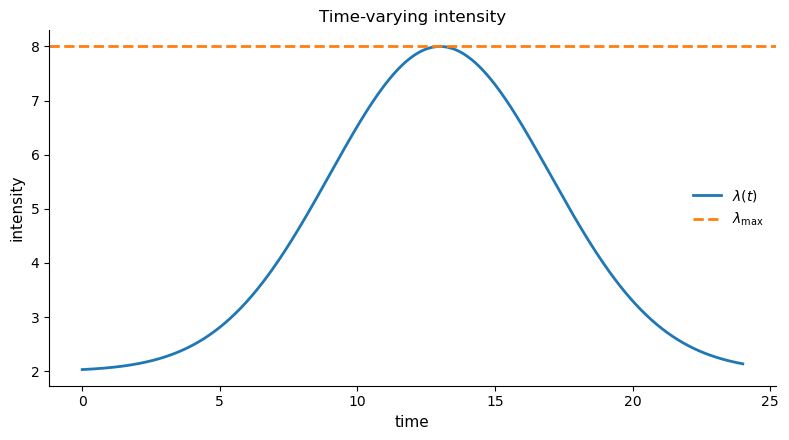

In [4]:
plt.figure(figsize=FIGSIZE)

plt.plot(
    t_grid,
    lambda_values,
    linewidth=2,
    label=r"$\lambda(t)$"
)

plt.axhline(
    lambda_max,
    color="C1",
    linestyle="--",
    linewidth=2,
    label=r"$\lambda_{\max}$"
)

plt.xlabel("time")
plt.ylabel("intensity")
plt.title("Time-varying intensity")
plt.legend()
plt.tight_layout()
plt.show()

The curve gives the event rate at each time. The dashed horizontal line is the constant upper rate used for thinning.

When $\lambda(t)$ is close to $\lambda_{\max}$, candidate events are likely to be accepted. When $\lambda(t)$ is small, many candidate events are rejected.

### Helper function

The next function simulates a nonhomogeneous Poisson process by thinning. It returns both candidate event times and accepted event times, so that the thinning step can be visualized.

In [5]:
def simulate_nhpp_thinning(T, intensity_func, lambda_max, rng=None):
    """Simulate a nonhomogeneous Poisson process by thinning."""
    if rng is None:
        rng = np.random.default_rng()
    if lambda_max <= 0:
        raise ValueError("lambda_max must be positive")

    # Generate candidate times from the dominating Poisson process
    candidate_times = []
    current_time = 0.0

    while current_time < T:
        waiting_time = rng.exponential(1 / lambda_max)
        current_time += waiting_time
        if current_time <= T:
            candidate_times.append(current_time)

    candidate_times = np.array(candidate_times)

    # Check that the intensity is valid at every candidate time
    candidate_rates = intensity_func(candidate_times)
    if np.any(candidate_rates < 0) or np.any(candidate_rates > lambda_max):
        raise ValueError("The intensity must lie between 0 and lambda_max")

    # Use vertical marks to make the thinning decisions visible
    candidate_heights = rng.uniform(0, lambda_max, len(candidate_times))
    accepted = candidate_heights <= candidate_rates

    accepted_times = candidate_times[accepted]
    rejected_times = candidate_times[~accepted]

    return candidate_times, accepted_times, rejected_times, candidate_heights

## Example 2: One simulated path

We now simulate one nonhomogeneous Poisson process using thinning. The accepted event times are used to build the counting process $N(t)$.

The path is a step function. It jumps by one whenever an accepted event occurs.

In [6]:
# Simulate one nonhomogeneous Poisson process
candidate_times, accepted_times, rejected_times, candidate_heights = simulate_nhpp_thinning(
    T=T,
    intensity_func=intensity,
    lambda_max=lambda_max,
    rng=rng
)

# Build the counting process from accepted event times
plot_times = np.concatenate(([0], accepted_times, [T]))
plot_counts = np.concatenate((
    [0],
    np.arange(1, len(accepted_times) + 1),
    [len(accepted_times)]
))

print("Number of candidate events:", len(candidate_times))
print("Number of accepted events:", len(accepted_times))
print("Number of rejected events:", len(rejected_times))

Number of candidate events: 193
Number of accepted events: 97
Number of rejected events: 96


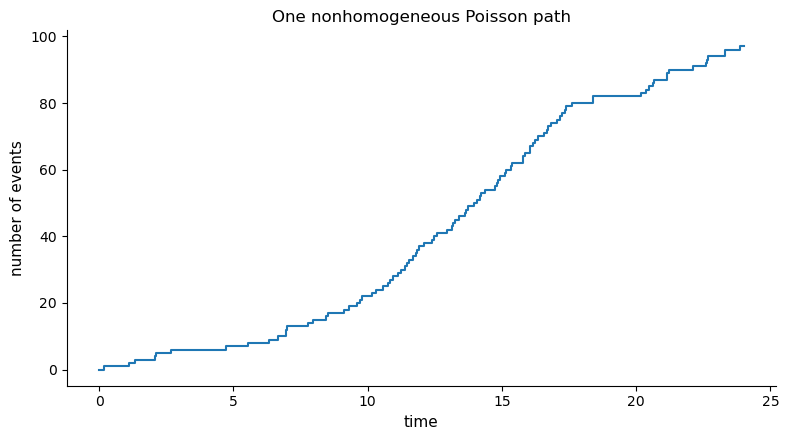

In [7]:
plt.figure(figsize=FIGSIZE)

plt.step(
    plot_times,
    plot_counts,
    where="post"
)

plt.xlabel("time")
plt.ylabel("number of events")
plt.title("One nonhomogeneous Poisson path")
plt.tight_layout()
plt.show()

This is one realization of the counting process. The jumps are not evenly spaced. More jumps tend to occur during the time interval where the intensity function is high.

The path should be read as one simulation, not as average behaviour.

## Example 3: Thinning construction

The same simulation can be viewed geometrically. Each candidate time is paired with a vertical mark sampled uniformly between $0$ and $\lambda_{\max}$. A point below $\lambda(t)$ is accepted, while a point above the curve is rejected.

The plot uses the actual marks generated for the path, so it shows the same accept or reject decisions as the counting process above.

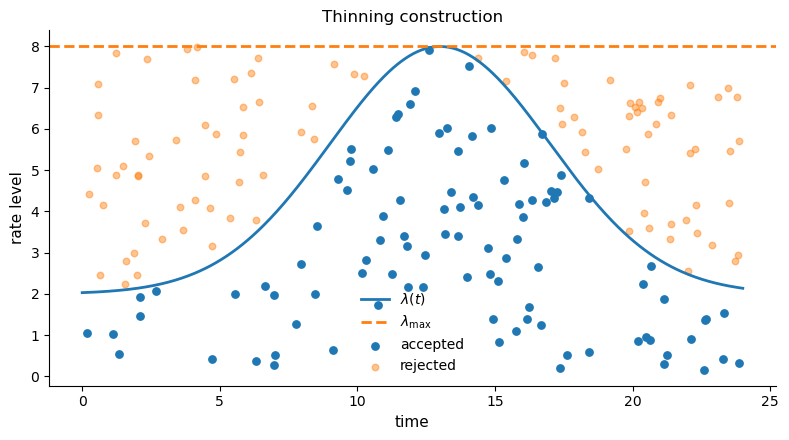

In [8]:
plt.figure(figsize=FIGSIZE)

# Split the actual candidate marks using the thinning rule
accepted_mask = candidate_heights <= intensity(candidate_times)
accepted_heights = candidate_heights[accepted_mask]
rejected_heights = candidate_heights[~accepted_mask]

plt.plot(
    t_grid,
    lambda_values,
    linewidth=2,
    label=r"$\lambda(t)$"
)

plt.axhline(
    lambda_max,
    color="C1",
    linestyle="--",
    linewidth=2,
    label=r"$\lambda_{\max}$"
)

plt.scatter(
    accepted_times,
    accepted_heights,
    s=28,
    label="accepted"
)

plt.scatter(
    rejected_times,
    rejected_heights,
    s=22,
    alpha=OVERLAP_ALPHA,
    label="rejected"
)

plt.xlabel("time")
plt.ylabel("rate level")
plt.title("Thinning construction")
plt.legend()
plt.tight_layout()
plt.show()

Every point below the intensity curve is accepted, and every point above it is rejected. The accepted points are denser around the busy period because the curve occupies a larger part of the candidate rectangle there. The plot therefore connects the acceptance rule with the changing event rate.

## Example 4: Many simulations and the mean count

A nonhomogeneous Poisson process has mean function $\mathbb{E}[N(t)]=\Lambda(0,t)$, where $\Lambda(0,t)=\int_0^t \lambda(s)\,ds$.

We now repeat the simulation many times and compare the average simulated count with the theoretical mean curve.

In [9]:
# Approximate the cumulative intensity on a fine grid
t_grid_mean = np.linspace(0, T, 400)
lambda_grid_mean = intensity(t_grid_mean)
dt = t_grid_mean[1] - t_grid_mean[0]

mean_curve = np.zeros_like(t_grid_mean)
mean_curve[1:] = np.cumsum(
    0.5 * (lambda_grid_mean[:-1] + lambda_grid_mean[1:]) * dt
)

print("Approximate expected total number of events:", mean_curve[-1])

Approximate expected total number of events: 107.94506966125316


In [10]:
n_mean_runs = 1000
t_grid_count = np.linspace(0, T, 200)
count_paths = []

# Record every simulated count path on the same time grid
for _ in range(n_mean_runs):
    _, accepted_run, _, _ = simulate_nhpp_thinning(
        T=T,
        intensity_func=intensity,
        lambda_max=lambda_max,
        rng=rng
    )

    count_path = np.searchsorted(
        accepted_run,
        t_grid_count,
        side="right"
    )

    count_paths.append(count_path)

# Rows represent simulations and columns represent time points
count_paths = np.array(count_paths)
mean_count_sim = count_paths.mean(axis=0)

print("Number of simulations:", n_mean_runs)
print("Average final count:", mean_count_sim[-1])

Number of simulations: 1000
Average final count: 107.993


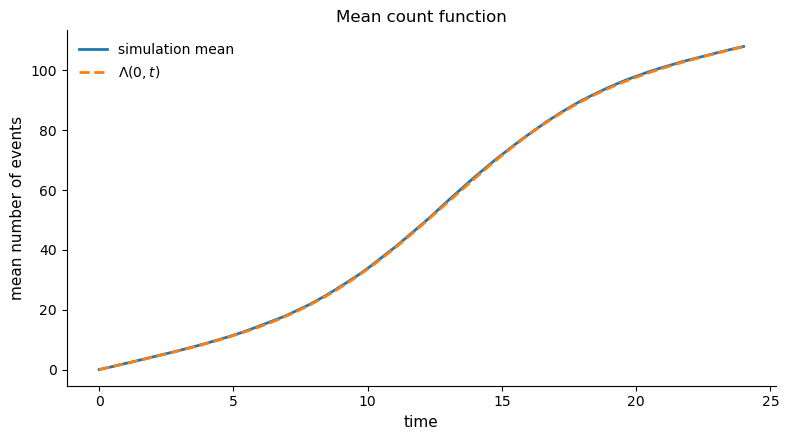

In [11]:
plt.figure(figsize=FIGSIZE)

plt.plot(
    t_grid_count,
    mean_count_sim,
    linewidth=2,
    label="simulation mean"
)

plt.plot(
    t_grid_mean,
    mean_curve,
    color="C1",
    linestyle="--",
    linewidth=2,
    label=r"$\Lambda(0,t)$"
)

plt.xlabel("time")
plt.ylabel("mean number of events")
plt.title("Mean count function")
plt.legend()
plt.tight_layout()
plt.show()

The solid curve is the average count from many simulations. The dashed curve is the theoretical mean function $\Lambda(0,t)$.

The two curves should be close when the number of simulations is large. This comparison checks that the thinning simulation produces the correct average event rate over time.

## Example 5: Event times and busy periods

The intensity function is highest near the middle of the interval. Accepted events should therefore appear more often near that time.

We compare this in two ways. A raster plot shows event times from several individual simulations, and a histogram summarizes event times collected from many simulations.

In [12]:
n_event_runs = 10000
all_event_times = []
n_raster_paths = 25
raster_event_times = []

# Pool event times for the histogram and retain a few paths for the raster
for run in range(n_event_runs):
    _, accepted_run, _, _ = simulate_nhpp_thinning(
        T=T,
        intensity_func=intensity,
        lambda_max=lambda_max,
        rng=rng
    )

    all_event_times.extend(accepted_run)

    if run < n_raster_paths:
        raster_event_times.append(accepted_run)

all_event_times = np.array(all_event_times)

print("Number of simulations:", n_event_runs)
print("Number of raster paths:", n_raster_paths)
print("Total number of accepted events:", len(all_event_times))

Number of simulations: 10000
Number of raster paths: 25
Total number of accepted events: 1080429


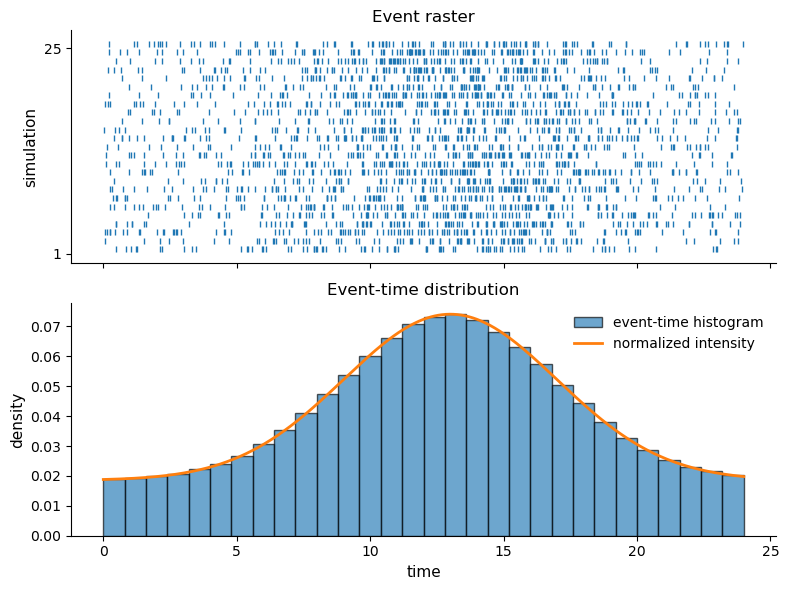

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Show where events occur in a few individual simulations
for row, event_times in enumerate(raster_event_times):
    axes[0].vlines(
        event_times,
        row + 0.15,
        row + 0.85,
        linewidth=1
    )

axes[0].set_ylabel("simulation")
axes[0].set_title("Event raster")
axes[0].set_yticks([0, n_raster_paths - 1])
axes[0].set_yticklabels(["1", str(n_raster_paths)])

# Compare pooled event times with the normalized intensity
axes[1].hist(
    all_event_times,
    bins=30,
    density=True,
    alpha=HIST_ALPHA,
    edgecolor="black",
    label="event-time histogram"
)

intensity_area = np.trapz(lambda_values, t_grid)
intensity_density = lambda_values / intensity_area

axes[1].plot(
    t_grid,
    intensity_density,
    color="C1",
    linewidth=2,
    label="normalized intensity"
)

axes[1].set_xlabel("time")
axes[1].set_ylabel("density")
axes[1].set_title("Event-time distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

The raster plot shows event times from several individual simulations. Each vertical mark represents one accepted event. Around the busy period, the marks become denser across different simulations.

Conditional on $N(T)=n>0$, the unordered event times have density

$$
f(t)=\frac{\lambda(t)}{\Lambda(0,T)},
\qquad 0\leq t\leq T.
$$

The histogram pools event times from many simulations and is compared with this normalized intensity. Both are concentrated around the busy period, where $\lambda(t)$ is large.